In [4]:
import numpy as np
import matplotlib.pyplot as plt     

In [2]:
%%bash
cd ..
g++ -std=c++17 -Wall Airfoil.cpp SRC/Mesh.cpp SRC/Flux.cpp SRC/Simulation.cpp SRC/Solver.cpp SRC/Cell.cpp -o myprogram

        

SRC/Flux.cpp: In function ‘double p_func(double, double, double, double)’:
SRC/Flux.cpp:447:10: warning: unused variable ‘den’ [-Wunused-variable]
  447 |     auto den = (1+r > 0) - (1+r < 0);
      |          ^~~
SRC/Flux.cpp: In member function ‘std::pair<std::array<double, 4>, std::array<double, 4> > Flux::MusclExtrapolation(Cell*, char)’:
SRC/Flux.cpp:471:26: warning: unused variable ‘tol’ [-Wunused-variable]
  471 |             const double tol = 1e-14;
      |                          ^~~
SRC/Flux.cpp: In member function ‘void Flux::compute_residual()’:
SRC/Flux.cpp:608:14: warning: unused variable ‘ghost_flag’ [-Wunused-variable]
  608 |         bool ghost_flag = false;
      |              ^~~~~~~~~~
SRC/Simulation.cpp: In member function ‘void Simulation::write_Cd(const string&)’:
SRC/Simulation.cpp:63:12: warning: unused variable ‘Cd’ [-Wunused-variable]
   63 |     double Cd = 0.0;
      |            ^~
SRC/Solver.cpp: In member function ‘void Solver::set_mms_bcs(Cell*)’:
SR

In [3]:
%%bash
cd ..
./myprogram

Shape = (9984, 4)
setting pointersSetting boundary types
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching con

In [24]:


data = np.loadtxt("../airfoil_primitives.csv", delimiter=",")
NI = 52
NJ = 192
print(data.shape)   # (4, Ncells)
rho = data[0, :].reshape((NI,NJ))
u   = data[1, :].reshape((NI,NJ))
v   = data[2, :].reshape((NI,NJ))
p   = data[3, :].reshape((NI,NJ))


(4, 9984)


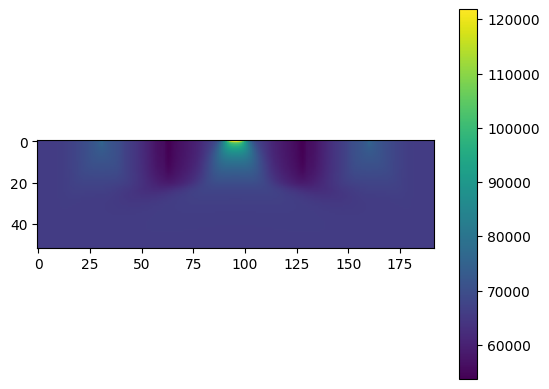

In [25]:
p = p.reshape((52,192))
plt.imshow(p)
plt.colorbar()

In [26]:
from PostprocessingFunctions import load_grid
# x,y = load_grid("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Airfoil/NACA64A006.coarse.53x27.grd")
x,y = load_grid("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Airfoil/NACA64A006.medium.193x53.grd")

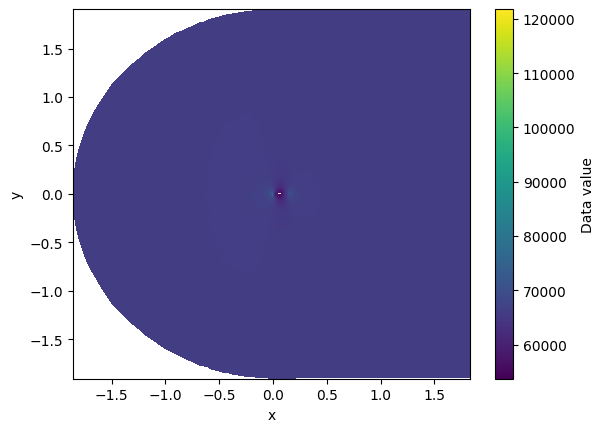

In [27]:
 

plt.pcolormesh(x[:,:], y[:,:], p[:,:], shading='auto', cmap='viridis')
plt.colorbar(label="Data value")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [69]:

nxi_top = -(y[:,1:]-y[:,0:-1])
nx = (-(nxi_top)[0:-1,:])[0,:]


In [70]:
p_inf = 65855.8
rho_inf = 0.764876
V_inf = 291.639
chord = .1524

In [71]:
p_at_face = p[0,:]+.5*(p[1,:]-p[0,:])

0.01071578776956455


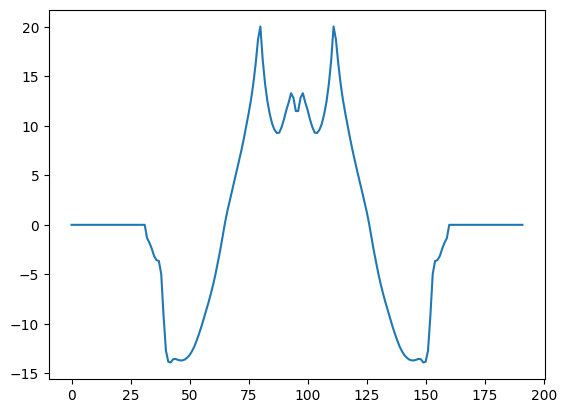

In [72]:
plt.plot(nx*p[0,:])
Den = (.5*rho_inf*V_inf**2)*chord
print("Drag Coefficient:",np.sum(nx*p_at_face)/Den)

In [73]:
y[0,17:-17] # 17 for NACA 53x27


array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -1.82103158e-05, -4.31367298e-05, -7.67583333e-05, -1.20985904e-04,
       -1.71355656e-04, -2.23194846e-04, -2.94131081e-04, -4.26154817e-04,
       -6.10603369e-04, -8.14269588e-04, -1.02144713e-03, -1.22524775e-03,
       -1.42985000e-03, -1.63764658e-03, -1.84821081e-03, -2.06065620e-03,
       -2.27382476e-03, -2.48618028e-03, -2.69677676e-03, -2.90353713e-03,
       -3.10509861e-03, -3.29872780e-03, -3.48356785e-03, -3.65841971e-03,
       -3.82202328e-03, -3.97346960e-03, -4.11214819e-03, -4.23593586e-03,
       -4.34299512e-03, -4.43189032e-03, -4.50131902e-03, -4.54878155e-03,
       -4.57055820e-03, -4.56711138e-03, -4.54232469e-03, -4.49911132e-03,
       -4.43821261e-03, -

In [74]:
Cd = np.loadtxt("/home/aaron99/src/CFD/CFD/CFD_FINAL3/drag_coef.csv",delimiter=",")

ValueError: could not convert string '-1.33859-1.81173-2.41955-3.15631-3.57018-3.65246-4.97766-9.23485-12.7261-13.8338-13.9081-13.5834-13 to float64 at row 0, column 1.

In [ ]:
rho_inf = 0.549873
c = .1524
V_inf = (273.01)**2
Cd/(rho_inf*c*V_inf*2)